In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import os

# **Lectura y caracteristicas principales de la base de datos de** *indicidencia delictiva a nivel municipal*

In [ ]:
archivo_incidencia_delictiva_municipal = os.path.join("..", "data", "raw", "incidencia_delictiva_municipal.csv")

df_municipal = pd.read_csv(archivo_incidencia_delictiva_municipal, encoding="latin-1")

df_municipal.head()

,Año,Clave_Ent,Entidad,Cve. Municipio,Municipio,Bien jurídico afectado,Tipo de delito,Subtipo de delito,Modalidad,Enero,...,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
0,2015,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,2,...,1,1,0,1,1,0,2,1,0,1
1,2015,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,1,...,0,0,0,1,0,1,0,0,0,0
2,2015,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,0,...,1,1,3,2,0,1,2,0,0,0
3,2015,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,1,...,0,1,0,0,0,0,0,0,0,0
4,2015,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio culposo,Con arma de fuego,0,...,0,0,1,0,0,0,0,0,0,0


In [6]:
df_municipal.rename(columns={
    "Año": "anio",
    "Clave_Ent": "clave_entidad",
    "Entidad": "entidad",
    "Cve. Municipio": "clave_municipio",
    "Municipio": "municipio",
    "Bien jurídico afectado":"bien_juridico_afectado",
    "Tipo de delito":"tipo_delito",
    "Subtipo de delito":"subtipo_delito",
    "Modalidad":"modalidad",
    "Enero":"enero", "Febrero":"febrero", "Marzo":"marzo", "Abril":"abril", "Mayo":"mayo", "Junio":"junio",
    "Julio":"julio", "Agosto":"agosto", "Septiembre":"septiembre", "Octubre":"octubre",
    "Noviembre":"noviembre", "Diciembre":"diciembre"},
    inplace=True)

df_municipal.head()

,anio,clave_entidad,entidad,clave_municipio,municipio,bien_juridico_afectado,tipo_delito,subtipo_delito,modalidad,enero,...,marzo,abril,mayo,junio,julio,agosto,septiembre,octubre,noviembre,diciembre
0,2015,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,2,...,1,1,0,1,1,0,2,1,0,1
1,2015,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,1,...,0,0,0,1,0,1,0,0,0,0
2,2015,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,0,...,1,1,3,2,0,1,2,0,0,0
3,2015,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,1,...,0,1,0,0,0,0,0,0,0,0
4,2015,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio culposo,Con arma de fuego,0,...,0,0,1,0,0,0,0,0,0,0


In [7]:
df_municipal_ordenado = df_municipal.melt(
    id_vars=[
        "entidad",
        "municipio",
        "anio",
        "tipo_delito",
        "subtipo_delito",
        "modalidad",
        "bien_juridico_afectado"
    ],
    value_vars=[
        "enero", "febrero", "marzo", "abril", "mayo", "junio",
        "julio", "agosto", "septiembre", "octubre", "noviembre", "diciembre"
    ],
    var_name="mes",
    value_name="incidencia_delictiva"
)

df_municipal_ordenado.head()

,entidad,municipio,anio,tipo_delito,subtipo_delito,modalidad,bien_juridico_afectado,mes,incidencia_delictiva
0,Aguascalientes,Aguascalientes,2015,Homicidio,Homicidio doloso,Con arma de fuego,La vida y la Integridad corporal,enero,2
1,Aguascalientes,Aguascalientes,2015,Homicidio,Homicidio doloso,Con arma blanca,La vida y la Integridad corporal,enero,1
2,Aguascalientes,Aguascalientes,2015,Homicidio,Homicidio doloso,Con otro elemento,La vida y la Integridad corporal,enero,0
3,Aguascalientes,Aguascalientes,2015,Homicidio,Homicidio doloso,No especificado,La vida y la Integridad corporal,enero,1
4,Aguascalientes,Aguascalientes,2015,Homicidio,Homicidio culposo,Con arma de fuego,La vida y la Integridad corporal,enero,0


In [8]:
df_municipal.shape

(2562994, 21)

In [9]:
numero = df_municipal.shape[0]
numero_formateado = f'{numero:,}'
print(numero_formateado)

2,562,994


In [10]:
len(df_municipal["municipio"].unique())

2337

In [11]:
df_municipal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2562994 entries, 0 to 2562993
Data columns (total 21 columns):
 #   Column                  Dtype 
---  ------                  ----- 
 0   anio                    int64 
 1   clave_entidad           int64 
 2   entidad                 object
 3   clave_municipio         int64 
 4   municipio               object
 5   bien_juridico_afectado  object
 6   tipo_delito             object
 7   subtipo_delito          object
 8   modalidad               object
 9   enero                   int64 
 10  febrero                 int64 
 11  marzo                   int64 
 12  abril                   int64 
 13  mayo                    int64 
 14  junio                   int64 
 15  julio                   int64 
 16  agosto                  int64 
 17  septiembre              int64 
 18  octubre                 int64 
 19  noviembre               int64 
 20  diciembre               int64 
dtypes: int64(15), object(6)
memory usage: 410.6+ MB


In [12]:
df_municipal_ordenado.shape

(30755928, 9)

In [13]:
numero = df_municipal_ordenado.shape[0]
numero_formateado = f'{numero:,}'
print(numero_formateado)

30,755,928


# **Conteo de las características principales:**

  - Tipo de delito
  - Subtipo de delito
  - Bien jurídico afectado
  - modalidad

**Muncipios con mayor indice delictivo a nivel nacional**

In [14]:
df_municipal_ordenado.groupby(["tipo_delito", "entidad", "municipio"])["incidencia_delictiva"].sum().sort_values(ascending=False).nlargest(10)

tipo_delito   entidad           municipio          
Robo          México            Ecatepec de Morelos    230961
              Jalisco           Guadalajara            217031
              Baja California   Tijuana                179005
              Querétaro         Querétaro              165817
              Ciudad de México  Cuauhtémoc             146332
              Puebla            Puebla                 140785
              Baja California   Mexicali               138382
              Ciudad de México  Iztapalapa             137080
              México            Toluca                 131557
Narcomenudeo  Guanajuato        León                   121245
Name: incidencia_delictiva, dtype: int64

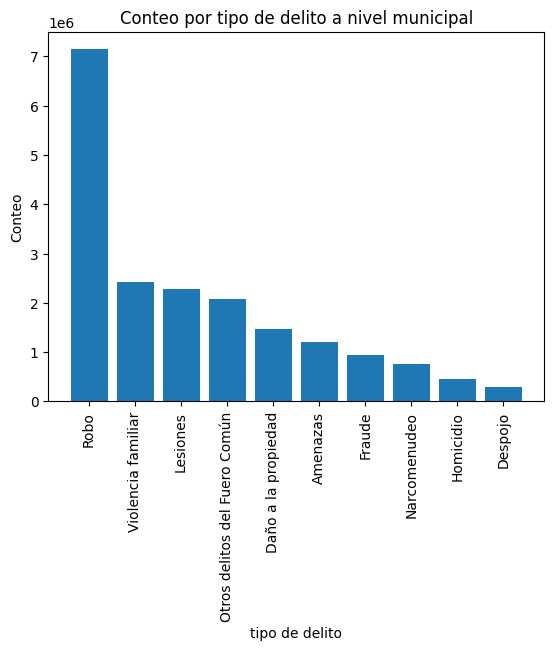

In [15]:
conteo = df_municipal_ordenado.groupby("tipo_delito")["incidencia_delictiva"].sum().sort_values(ascending=False).nlargest(10)

top_tipos_delitos = conteo.index
conteo_top_tipo_delitos = conteo.values

plt.bar(top_tipos_delitos, conteo_top_tipo_delitos)
plt.xlabel("tipo de delito")
plt.ylabel("Conteo")
plt.title("Conteo por tipo de delito a nivel municipal")
plt.xticks(rotation=90)

plt.show()

In [16]:
df_municipal_ordenado.groupby("subtipo_delito")["incidencia_delictiva"].sum().sort_values(ascending=False).nlargest(10)

,incidencia_delictiva
subtipo_delito,
Violencia familiar,2415195
Otros robos,2104880
Otros delitos del Fuero Común,2076199
Robo de vehículo automotor,1760492
Lesiones dolosas,1711871
Daño a la propiedad,1473104
Amenazas,1204821
Robo a negocio,985595
Fraude,934139


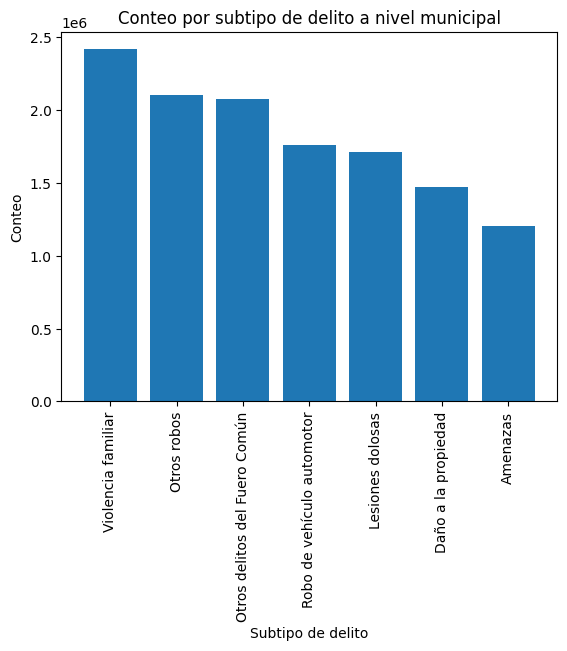

In [17]:
top_subtipos = df_municipal_ordenado.groupby("subtipo_delito")["incidencia_delictiva"].sum().sort_values(ascending=False).nlargest(7).index

conteo_top_subtipo_delitos = df_municipal_ordenado.groupby("subtipo_delito")["incidencia_delictiva"].sum().sort_values(ascending=False).nlargest(7).values

plt.bar(top_subtipos, conteo_top_subtipo_delitos)
plt.xlabel("Subtipo de delito")
plt.ylabel("Conteo")
plt.title("Conteo por subtipo de delito a nivel municipal")
plt.xticks(rotation=90)

plt.show()

In [18]:
df_municipal_ordenado.groupby("bien_juridico_afectado")["incidencia_delictiva"].sum().sort_values(ascending=False)

,incidencia_delictiva
bien_juridico_afectado,
El patrimonio,10367435
Otros bienes jurídicos afectados (del fuero común),4658198
La familia,2865532
La vida y la Integridad corporal,2847121
La libertad y la seguridad sexual,660844
Libertad personal,234352
La sociedad,98628


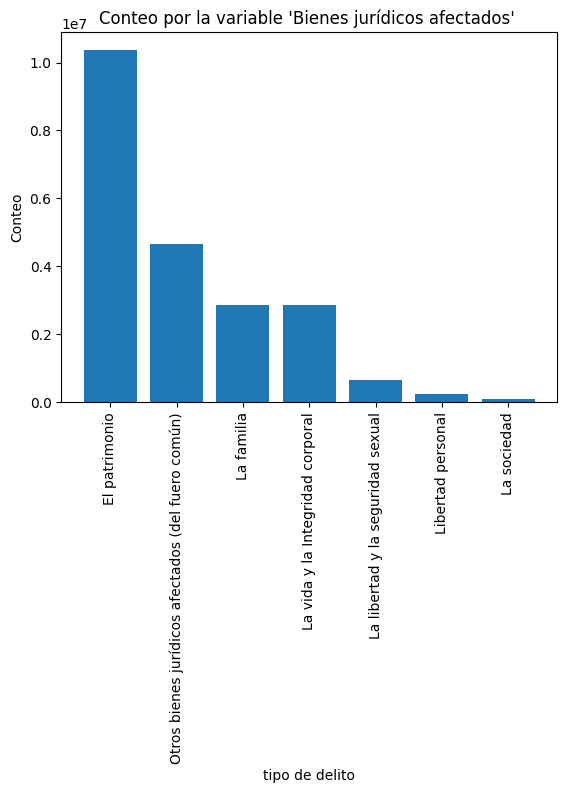

In [19]:
conteo = df_municipal_ordenado.groupby("bien_juridico_afectado")["incidencia_delictiva"].sum().sort_values(ascending=False)

bien_juridicos_afectados = conteo.index

conteo_bien_juridicos_afectados = conteo.values


plt.bar(bien_juridicos_afectados, conteo_bien_juridicos_afectados)
plt.xlabel("tipo de delito")
plt.ylabel("Conteo")
plt.title("Conteo por la variable 'Bienes jurídicos afectados' ")
plt.xticks(rotation=90)

plt.show()

In [20]:
df_municipal_ordenado.groupby("modalidad")["incidencia_delictiva"].sum().sort_values(ascending=False).nlargest(10)

,incidencia_delictiva
modalidad,
Sin violencia,3519288
Violencia familiar,2415195
Otros delitos del Fuero Común,2076199
Con violencia,1842278
Con otro elemento,1532018
Daño a la propiedad,1473104
Amenazas,1204821
Fraude,934139
Robo de coche de 4 ruedas Sin violencia,894617


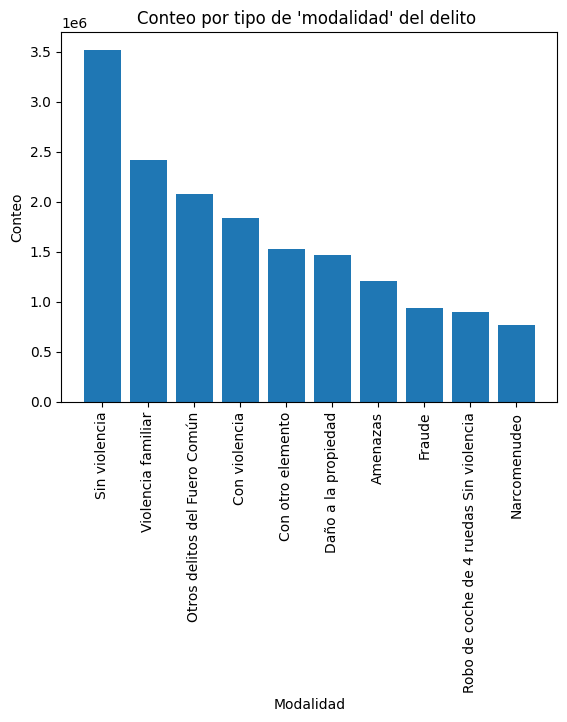

In [21]:
conteo = df_municipal_ordenado.groupby("modalidad")["incidencia_delictiva"].sum().sort_values(ascending=False).nlargest(10)

top_modalidades = conteo.index

top_conteo_modalidades = conteo.values

plt.bar(top_modalidades, top_conteo_modalidades)
plt.xlabel("Modalidad")
plt.ylabel("Conteo")
plt.title("Conteo por tipo de 'modalidad' del delito ")
plt.xticks(rotation=90)

plt.show()

# **Creación de dataframe a analizar**

In [46]:
df_filtrado = df_municipal_ordenado[
      (
          df_municipal_ordenado["tipo_delito"].isin(
              df_municipal_ordenado.groupby("tipo_delito")["incidencia_delictiva"].sum().sort_values(ascending=False).nlargest(6).index)
          )
    | (
        df_municipal_ordenado["subtipo_delito"].isin(
            df_municipal_ordenado.groupby("subtipo_delito")["incidencia_delictiva"].sum().sort_values(ascending=False).nlargest(6).index)
        )
    | (df_municipal_ordenado["modalidad"].isin(
        df_municipal_ordenado.groupby("modalidad")["incidencia_delictiva"].sum().sort_values(ascending=False).nlargest(7))
    )
]

df_filtrado.head()

,entidad,municipio,anio,tipo_delito,subtipo_delito,modalidad,bien_juridico_afectado,mes,incidencia_delictiva
9,Aguascalientes,Aguascalientes,2015,Lesiones,Lesiones dolosas,Con arma de fuego,La vida y la Integridad corporal,enero,1
10,Aguascalientes,Aguascalientes,2015,Lesiones,Lesiones dolosas,Con arma blanca,La vida y la Integridad corporal,enero,11
11,Aguascalientes,Aguascalientes,2015,Lesiones,Lesiones dolosas,Con otro elemento,La vida y la Integridad corporal,enero,120
12,Aguascalientes,Aguascalientes,2015,Lesiones,Lesiones dolosas,No especificado,La vida y la Integridad corporal,enero,10
13,Aguascalientes,Aguascalientes,2015,Lesiones,Lesiones culposas,Con arma de fuego,La vida y la Integridad corporal,enero,0


In [23]:
df_filtrado.shape

(15377964, 9)

In [24]:
numero = df_filtrado.shape[0]
numero_formateado = f'{numero:,}'
print(numero_formateado)

15,377,964


# **Frecuencia de tipo de delitos por entidad**

Tipo de delitos tomados en cuenta:
  - Amenazas
  - Daños a la propiedad
  - Fraude
  - Lesiones
  - Otros delitos del fuero común
  - Robo
  - Violencia familiar


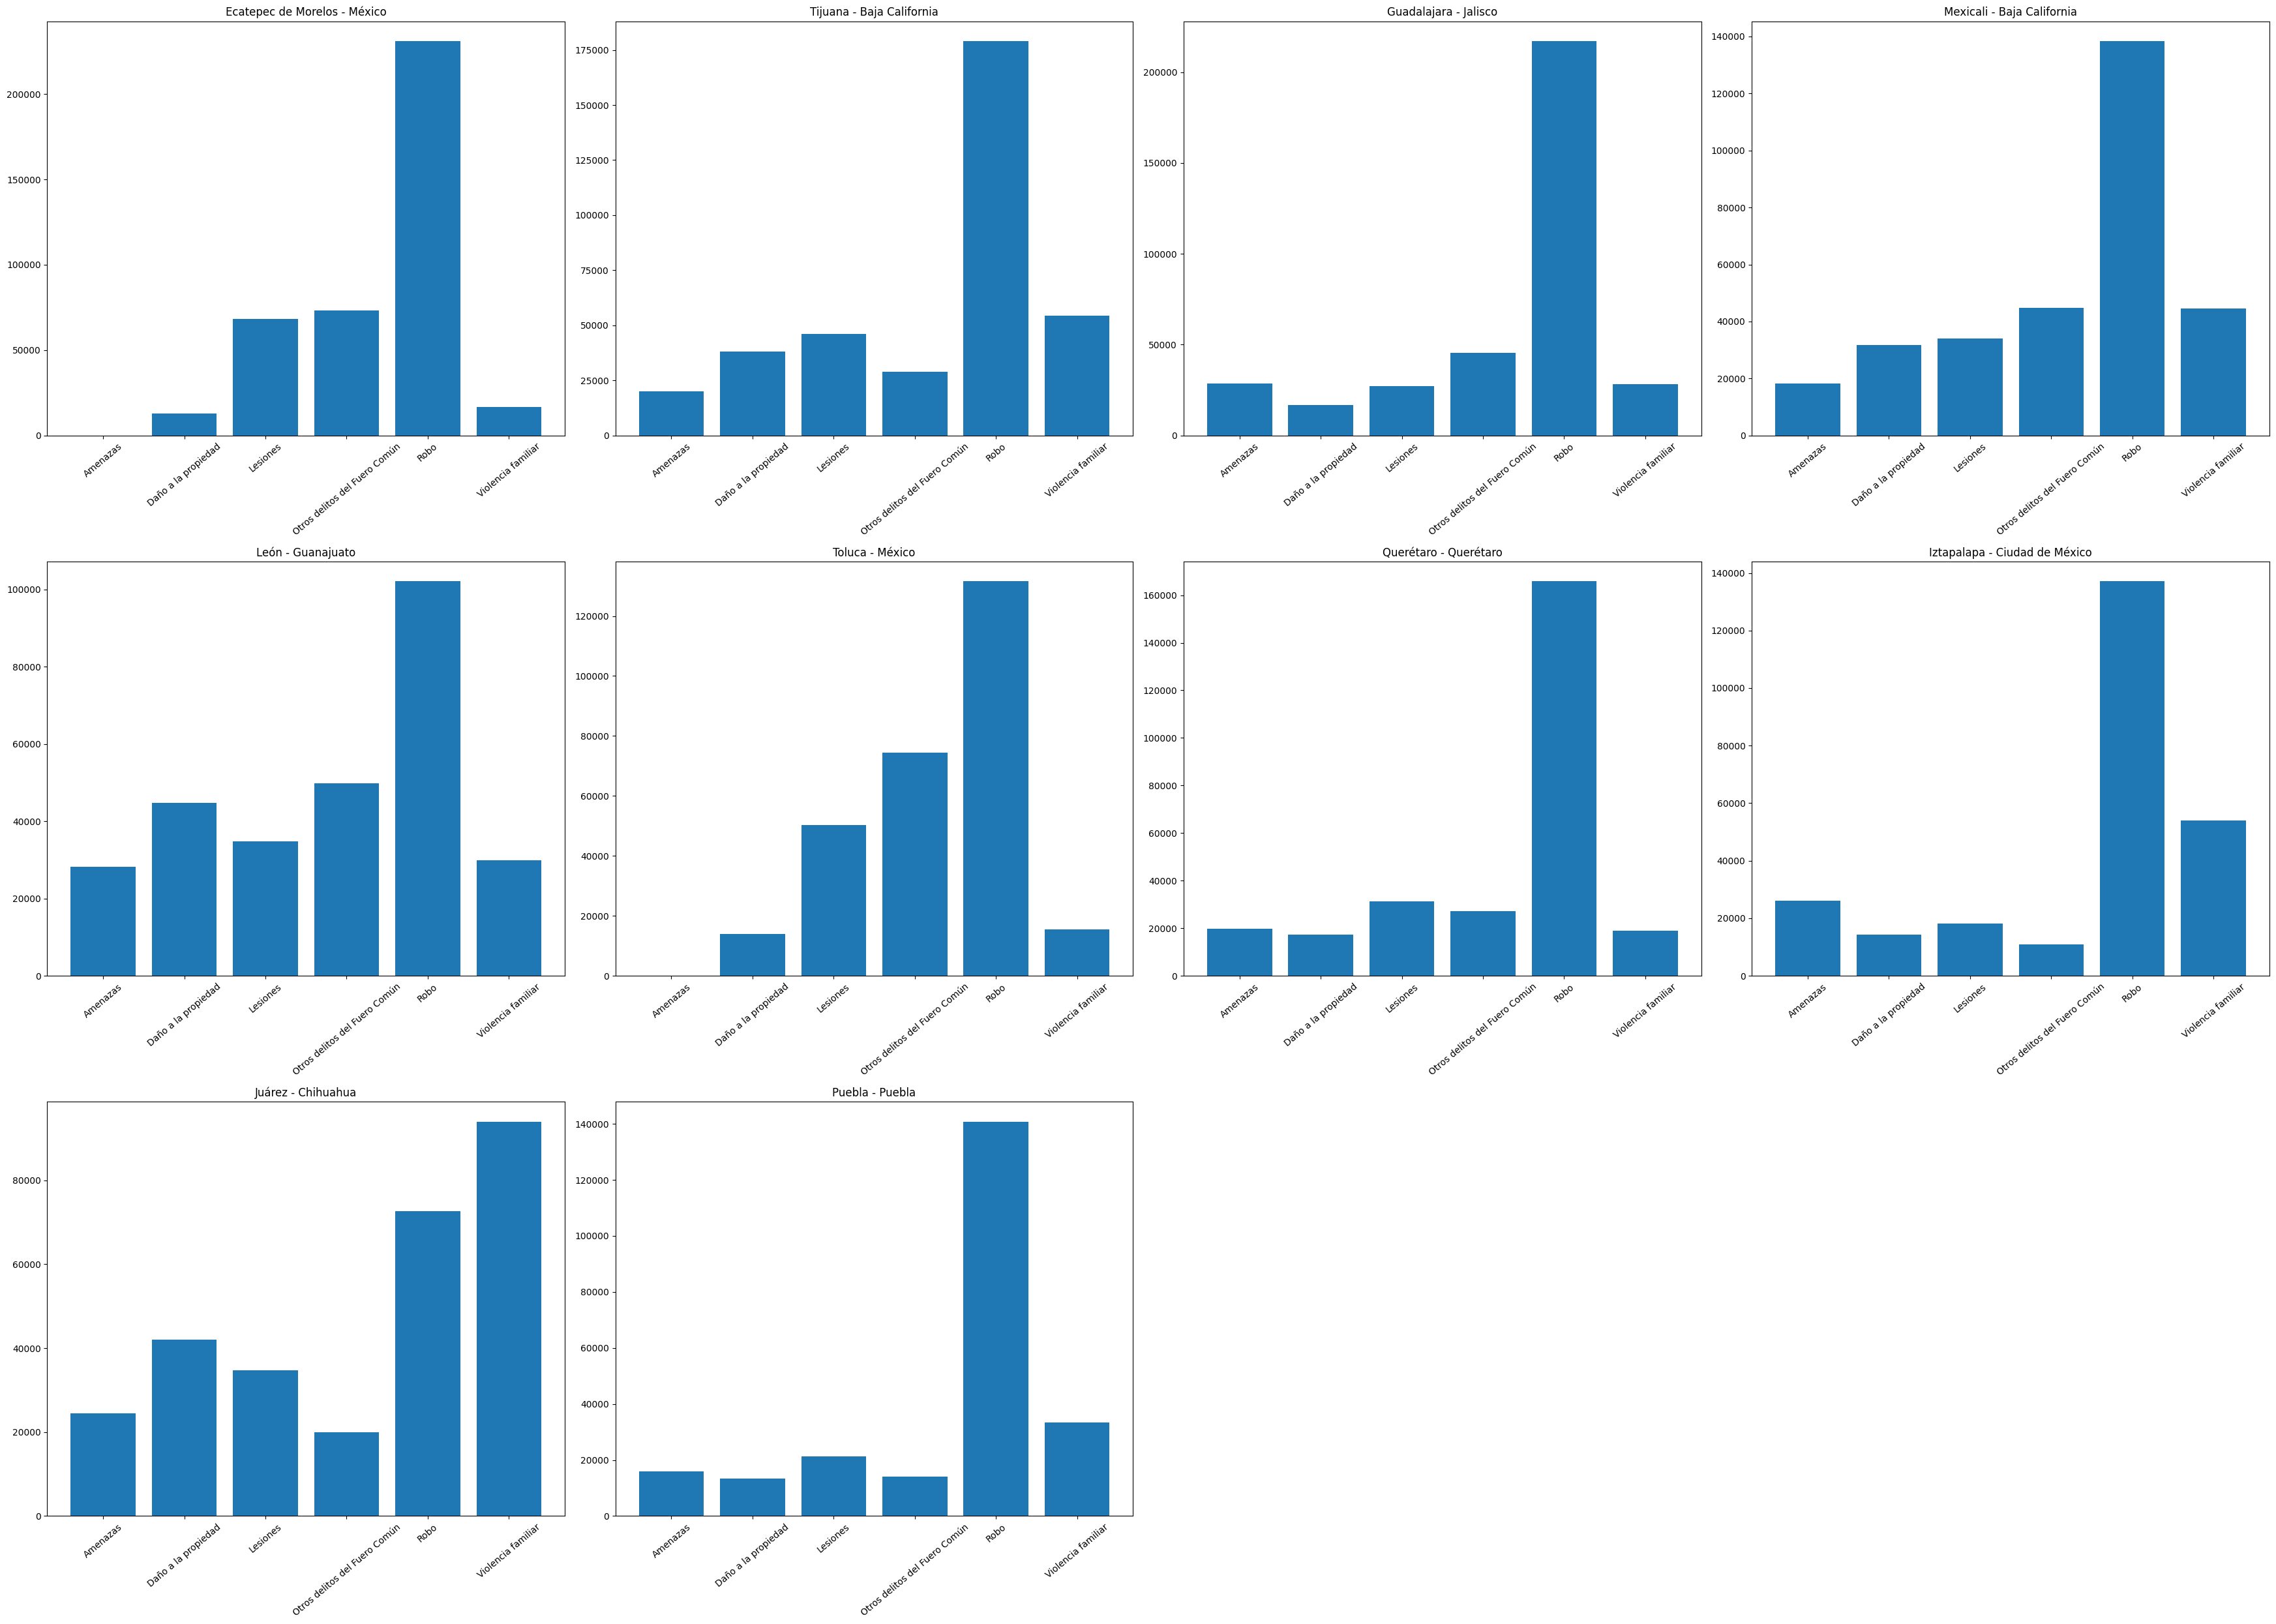

In [25]:
datos = df_filtrado.groupby(["entidad","municipio"])["incidencia_delictiva"].sum().sort_values(ascending=False).nlargest(10)

n_cols = 4
n_rows = math.ceil(len(datos) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(35, 25))
axes = axes.flatten()

for i, (entidad, municipio) in enumerate(datos.index):

    data = df_filtrado[df_filtrado["municipio"] == municipio]

    counts = data.groupby("tipo_delito")["incidencia_delictiva"].sum()

    axes[i].bar(
        counts.index,
        counts.values
    )

    axes[i].set_title(f"{municipio} - {entidad}")
    axes[i].tick_params(axis='x', rotation=40)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# **Linea del tiempo de los 10 municipios con más delitos desde:** *2015-2025*

0 México Ecatepec de Morelos
1 Jalisco Guadalajara
2 Baja California Tijuana
3 Querétaro Querétaro
4 Ciudad de México Cuauhtémoc
5 Puebla Puebla
6 Baja California Mexicali
7 Ciudad de México Iztapalapa
8 México Toluca
9 México Naucalpan de Juárez


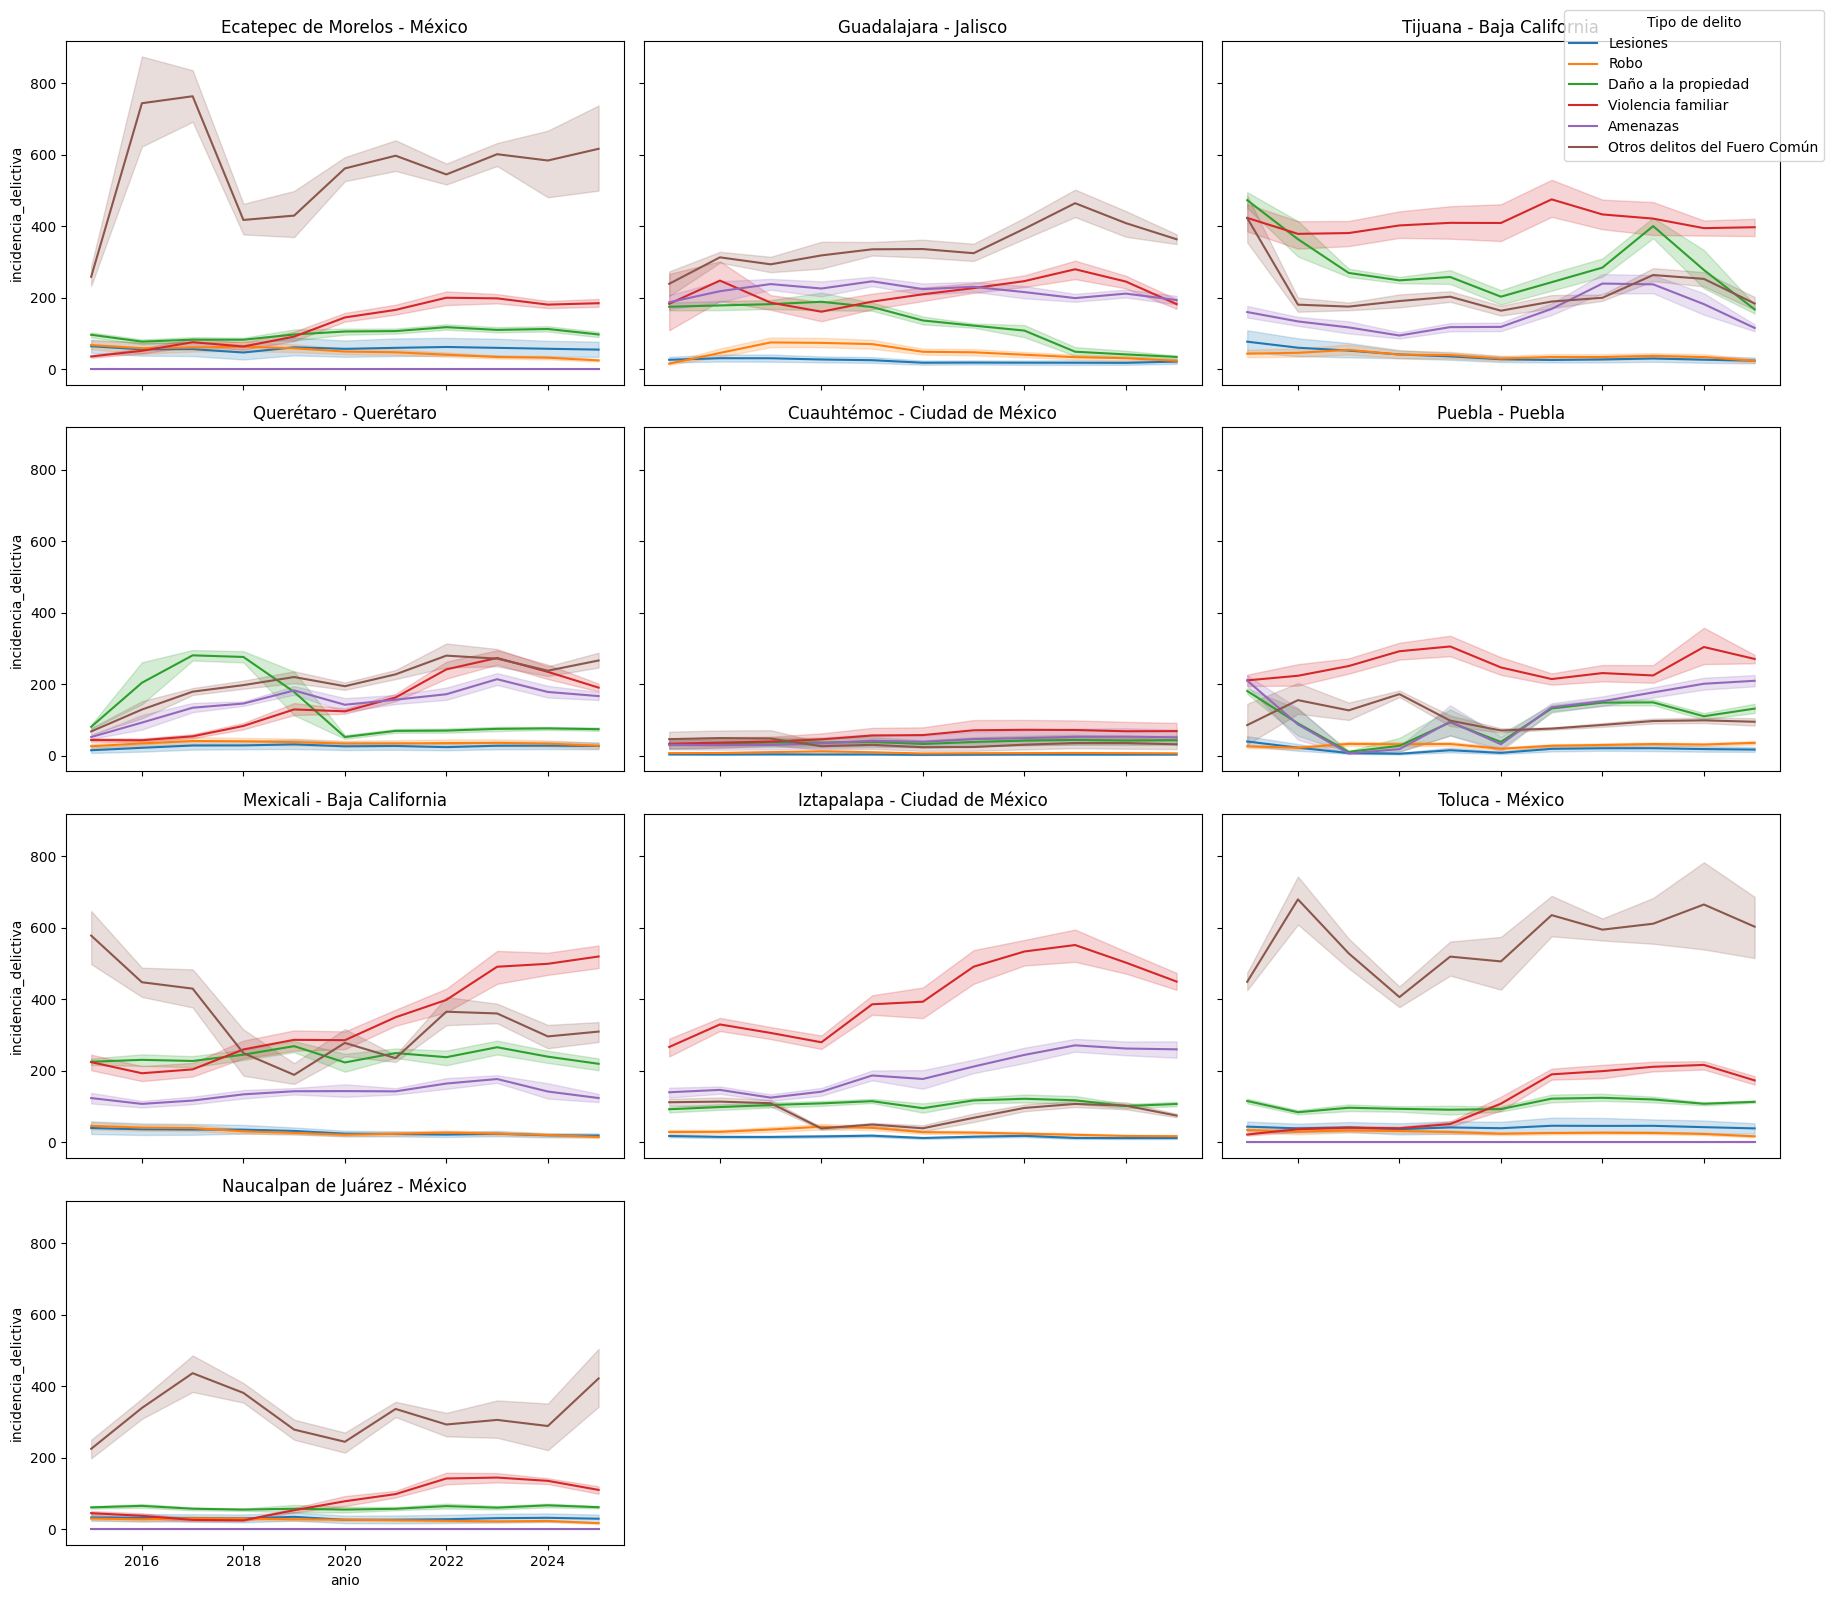

In [26]:
df_grouped = (
    df_filtrado.groupby(["entidad", "municipio", "tipo_delito"], as_index=False)["incidencia_delictiva"]
    .sum()
)

conteo = df_filtrado.groupby(["entidad", "municipio", "tipo_delito"], as_index=False)["incidencia_delictiva"].sum().nlargest(10, "incidencia_delictiva")
estados_municipios = conteo[["entidad", "municipio"]]
n_municipios = len(estados_municipios)

cols = 3
rows = math.ceil(n_municipios / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4), sharex=True, sharey=True)
axes = axes.flatten()

for i, (entidad, municipio) in enumerate(estados_municipios.values):
    print(i, entidad, municipio)

    df_municipio = df_filtrado[df_filtrado["municipio"] == municipio]

    sns.lineplot(
        data=df_municipio,
        x="anio",
        y="incidencia_delictiva",
        hue="tipo_delito",
        ax=axes[i]
    )

    axes[i].set_title(f"{municipio} - {entidad}")
    axes[i].legend().remove()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Tipo de delito", bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()



# **Conjunto de mapas de calor de la frecuencia de** *incidencia delictiva por año y municipio*

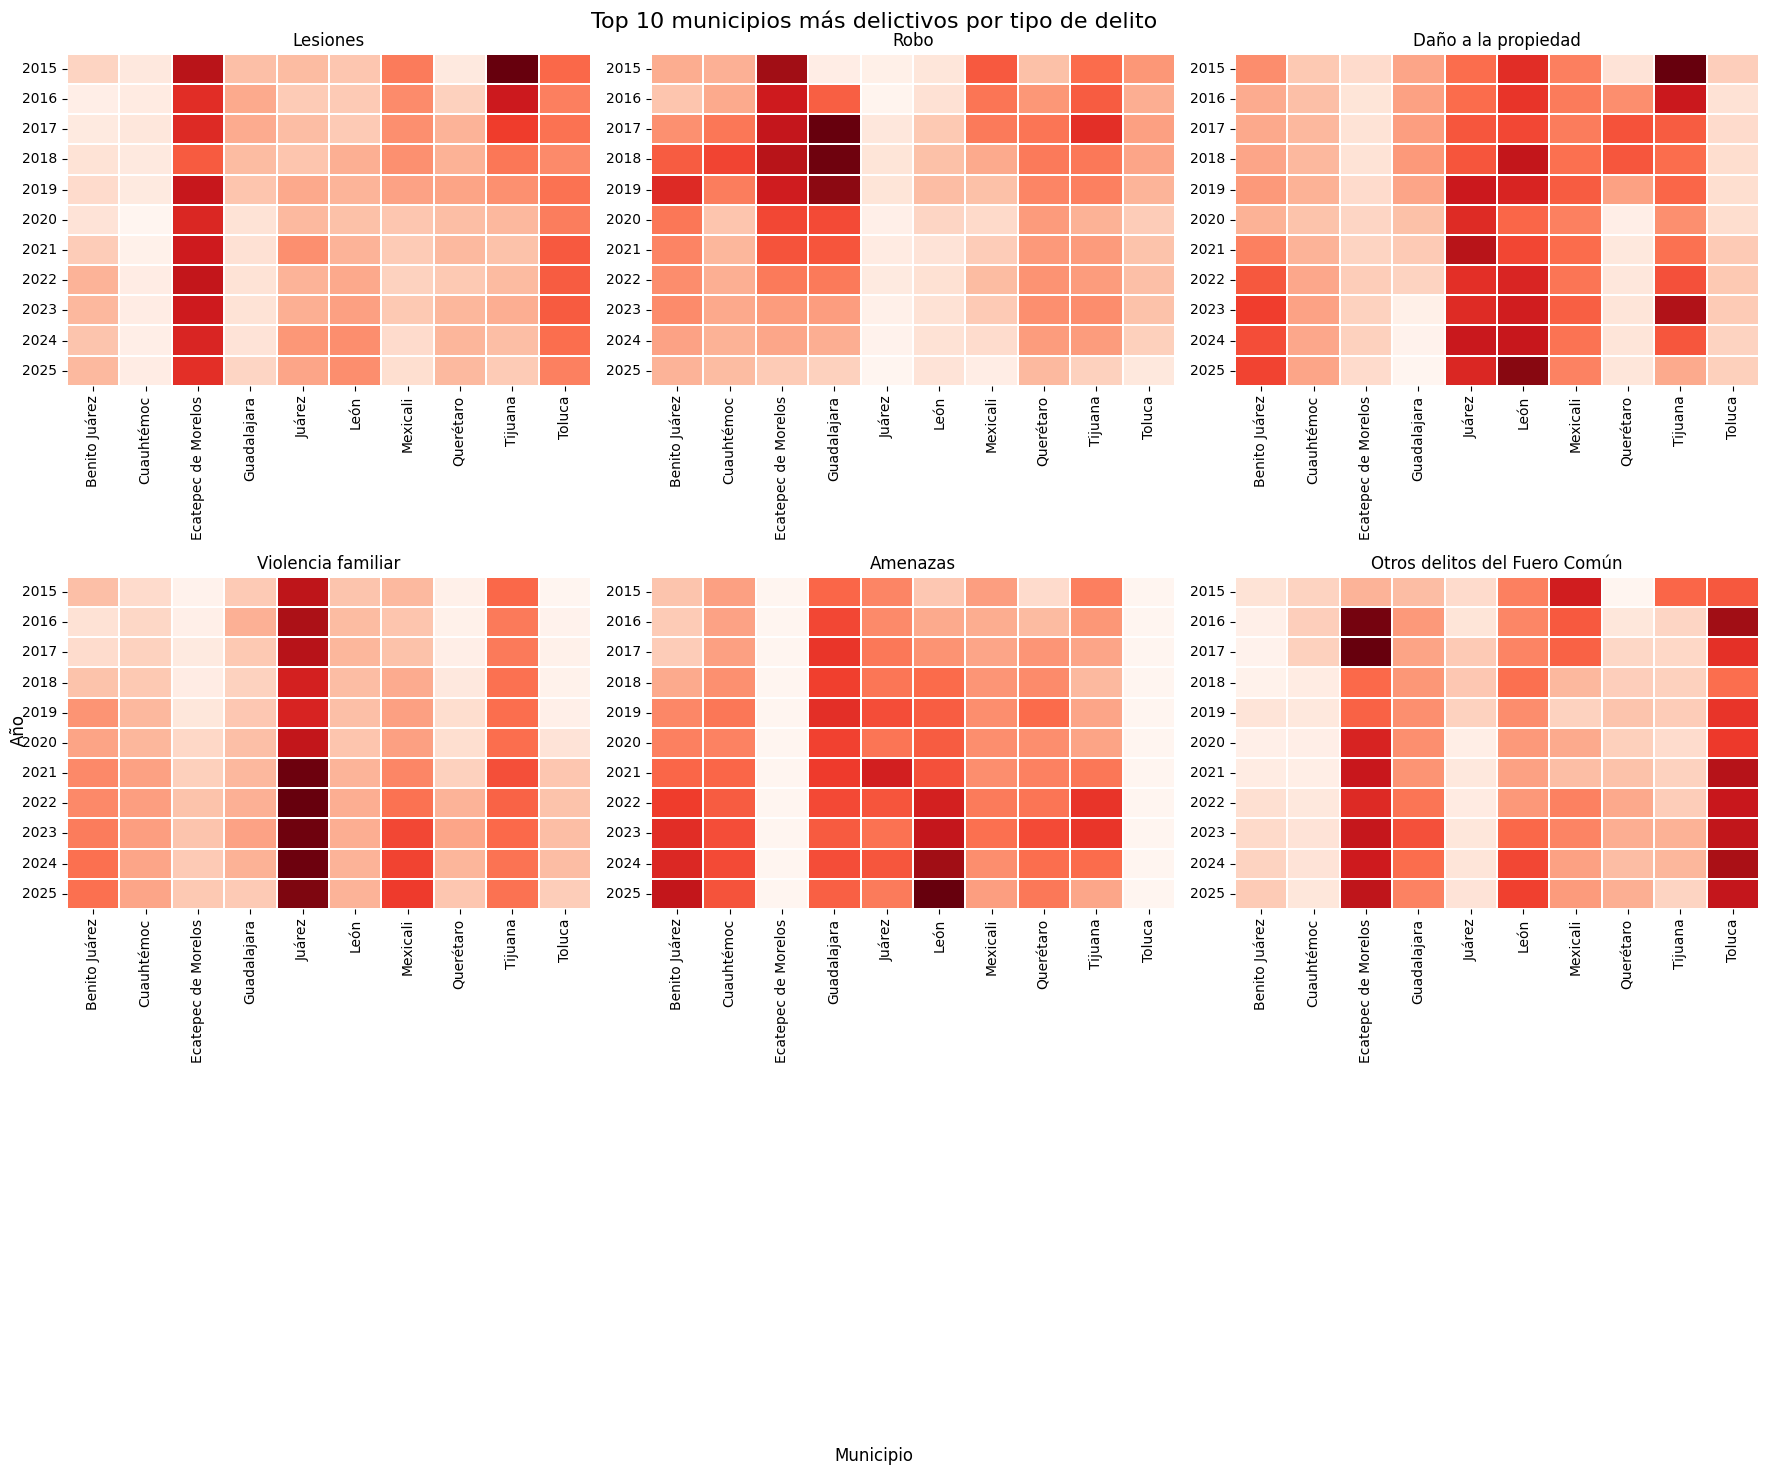

In [27]:
top_municipios = (
    df_filtrado
    .groupby(["municipio"])["incidencia_delictiva"]
    .sum()
    .nlargest(10)
    .index
)

df_top = df_filtrado[df_filtrado["municipio"].isin(top_municipios)]

delitos = df_top["tipo_delito"].unique()

n_cols = 3
n_rows = (len(delitos) // n_cols) + 1

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, delito in enumerate(delitos):
    ax = axes[i]

    df_filtrado_ = df_top[df_top["tipo_delito"] == delito]

    df_grouped = df_filtrado_.groupby(
        ["anio", "municipio"]
    )["incidencia_delictiva"].sum().reset_index()

    df_pivot = df_grouped.pivot(
        index="anio",
        columns="municipio",
        values="incidencia_delictiva"
    ).fillna(0)

    sns.heatmap(df_pivot, cmap="Reds", linewidths=0.3, ax=ax, cbar=False)

    ax.set_title(delito)
    ax.set_xlabel("")
    ax.set_ylabel("")

for j in range(len(delitos), len(axes)):
    fig.delaxes(axes[j])

fig.supxlabel("Municipio")
fig.supylabel("Año")
fig.suptitle("Top 10 municipios más delictivos por tipo de delito", fontsize=16)

plt.tight_layout()
plt.show()

# **Conjunto de lineas de tiempo de la** *incidencia delictiva por año, municipio y tipo de delito*

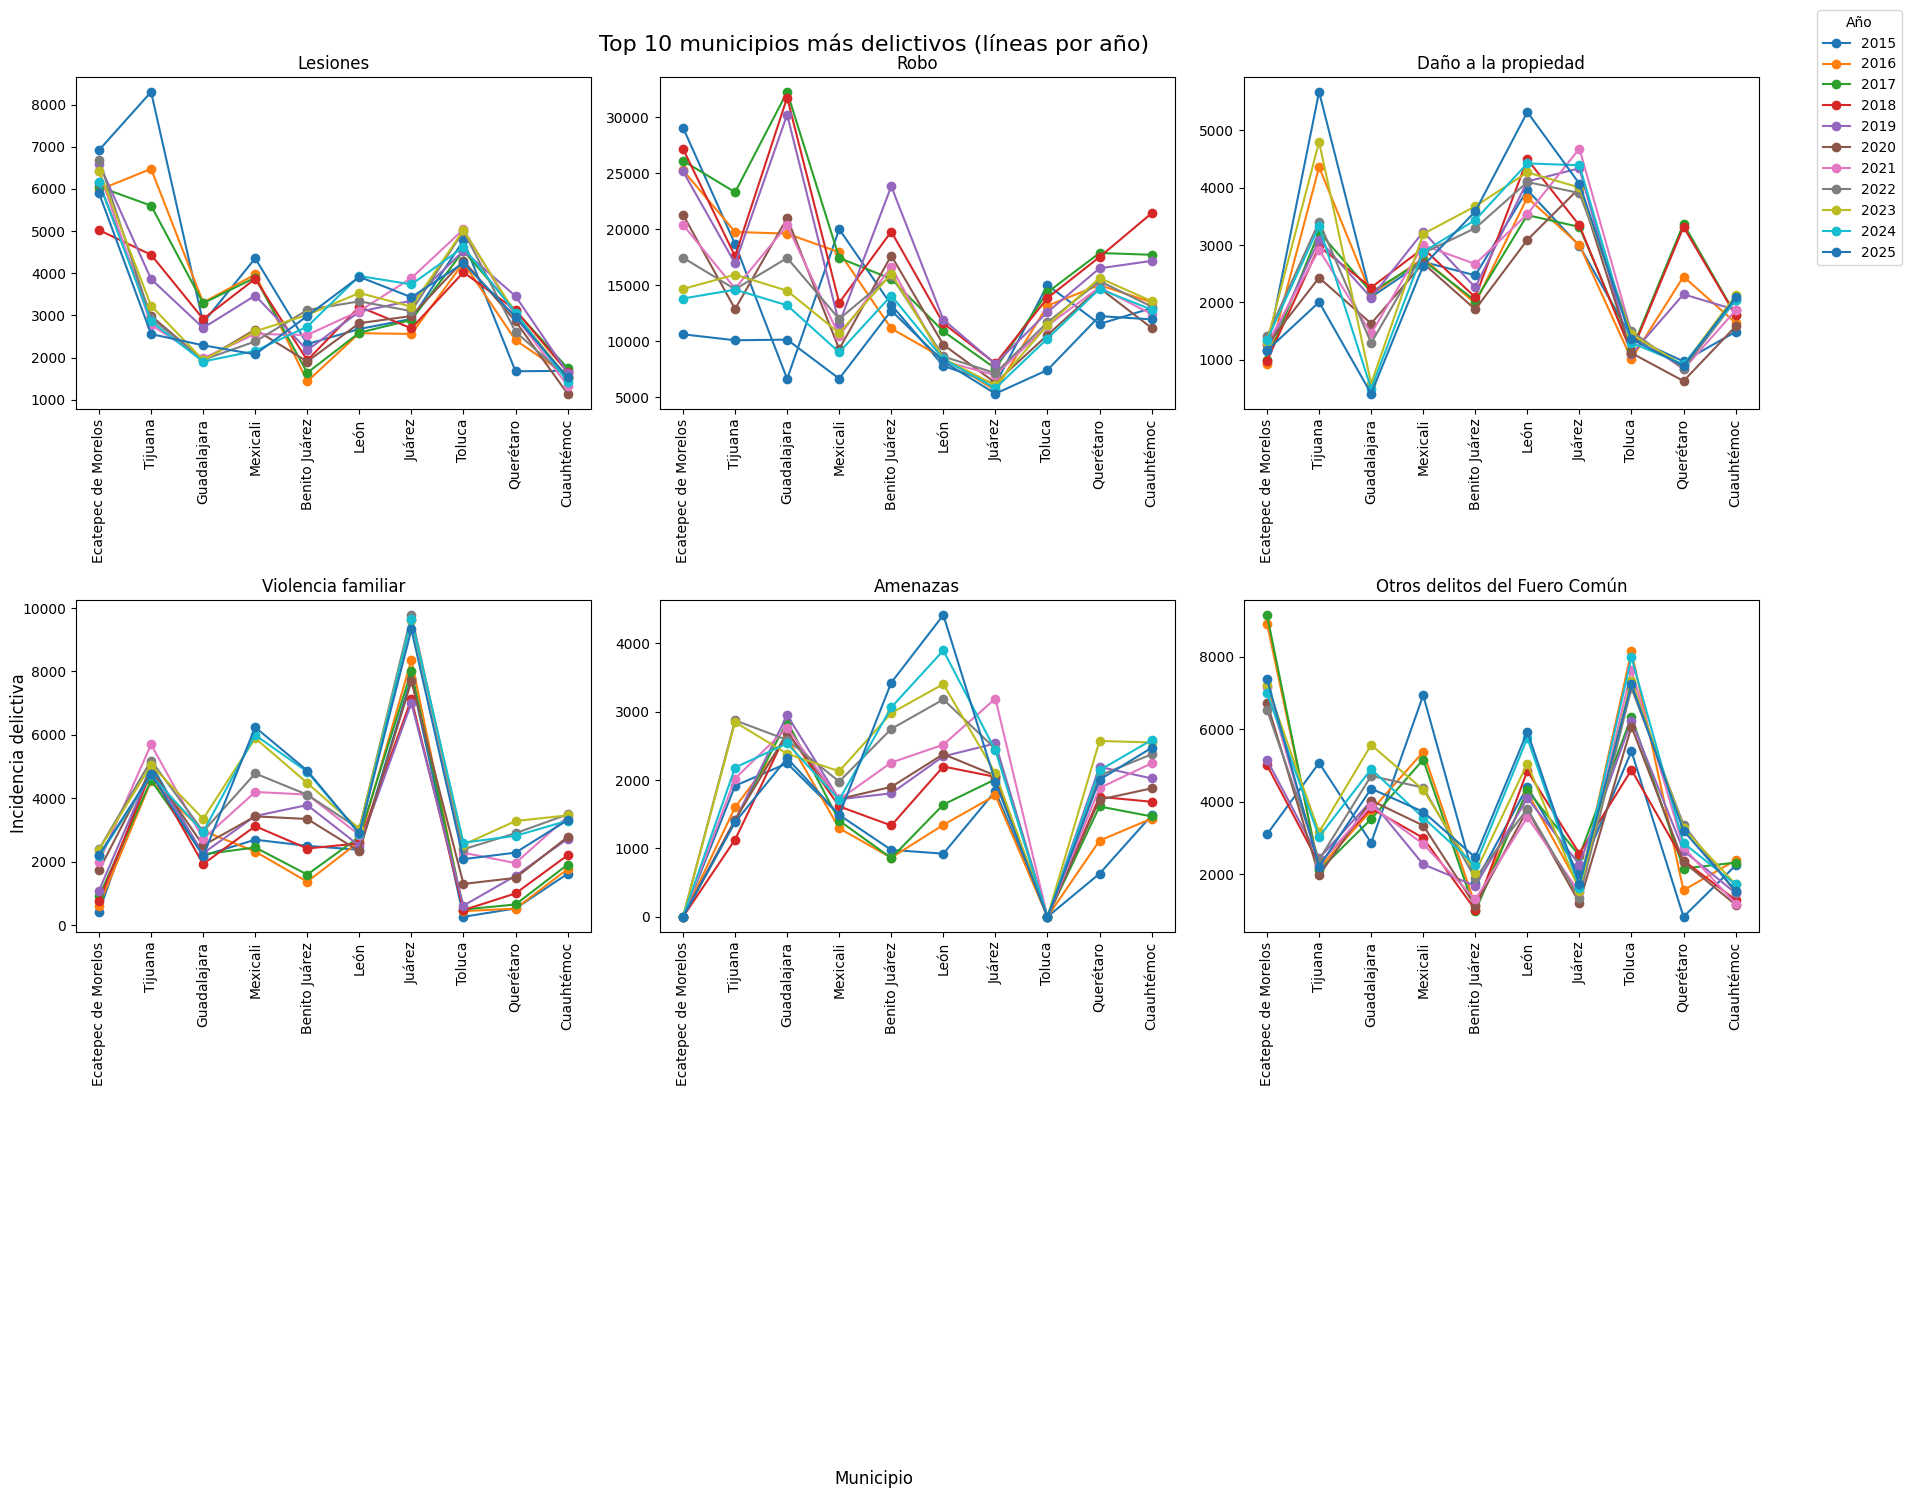

In [28]:
top_municipios = (
    df_filtrado
    .groupby("municipio")["incidencia_delictiva"]
    .sum()
    .nlargest(10)
    .index
)

df_top = df_filtrado[
    df_filtrado["municipio"].isin(top_municipios)
]

delitos = df_top["tipo_delito"].unique()

n_cols = 3
n_rows = (len(delitos) // n_cols) + 1

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, delito in enumerate(delitos):
    ax = axes[i]

    df_filtrado = df_top[df_top["tipo_delito"] == delito]

    df_grouped = df_filtrado.groupby(
        ["municipio", "anio"]
    )["incidencia_delictiva"].sum().reset_index()

    df_pivot = df_grouped.pivot(
        index="municipio",
        columns="anio",
        values="incidencia_delictiva"
    ).fillna(0)

    orden = df_pivot.sum(axis=1).sort_values(ascending=False).index
    df_pivot = df_pivot.loc[orden]

    df_pivot = df_pivot.loc[top_municipios]

    for anio in df_pivot.columns:
        ax.plot(df_pivot.index, df_pivot[anio], marker='o', label=anio)

    ax.set_title(delito)
    ax.tick_params(axis='x', rotation=90)

for j in range(len(delitos), len(axes)):
    fig.delaxes(axes[j])

fig.supxlabel("Municipio")
fig.supylabel("Incidencia delictiva")
fig.suptitle("Top 10 municipios más delictivos (líneas por año)", fontsize=16)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Año", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()



# **Aplicación de modelos no-supervisados**

In [ ]:
df_filtrado = df_municipal_ordenado[
      (
          df_municipal_ordenado["tipo_delito"].isin(
              df_municipal_ordenado.groupby("tipo_delito")["incidencia_delictiva"].sum().sort_values(ascending=False).nlargest(6).index)
          )
    | (
        df_municipal_ordenado["subtipo_delito"].isin(
            df_municipal_ordenado.groupby("subtipo_delito")["incidencia_delictiva"].sum().sort_values(ascending=False).nlargest(6).index)
        )
    | (df_municipal_ordenado["modalidad"].isin(
        df_municipal_ordenado.groupby("modalidad")["incidencia_delictiva"].sum().sort_values(ascending=False).nlargest(7))
    )
]

In [47]:
df_filtrado.head()

,entidad,municipio,anio,tipo_delito,subtipo_delito,modalidad,bien_juridico_afectado,mes,incidencia_delictiva
9,Aguascalientes,Aguascalientes,2015,Lesiones,Lesiones dolosas,Con arma de fuego,La vida y la Integridad corporal,enero,1
10,Aguascalientes,Aguascalientes,2015,Lesiones,Lesiones dolosas,Con arma blanca,La vida y la Integridad corporal,enero,11
11,Aguascalientes,Aguascalientes,2015,Lesiones,Lesiones dolosas,Con otro elemento,La vida y la Integridad corporal,enero,120
12,Aguascalientes,Aguascalientes,2015,Lesiones,Lesiones dolosas,No especificado,La vida y la Integridad corporal,enero,10
13,Aguascalientes,Aguascalientes,2015,Lesiones,Lesiones culposas,Con arma de fuego,La vida y la Integridad corporal,enero,0


In [50]:
print(df_filtrado["tipo_delito"].unique())

['Lesiones' 'Robo' 'Daño a la propiedad' 'Violencia familiar' 'Amenazas'
 'Otros delitos del Fuero Común']


In [49]:
df_pivot = df_filtrado.pivot_table(
    index=["entidad", "municipio"],
    columns="tipo_delito",
    values="incidencia_delictiva",
    aggfunc="sum",
    fill_value=0
).reset_index()


In [51]:
X = df_pivot.drop(columns=["entidad", "municipio"])

In [52]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df_pivot["cluster"] = clusters

In [53]:
df_pivot.groupby("cluster").mean(numeric_only=True)

tipo_delito,Amenazas,Daño a la propiedad,Lesiones,Otros delitos del Fuero Común,Robo,Violencia familiar
cluster,,,,,,
0,4910.792683,5935.024390,8702.182927,8324.756098,31017.268293,10566.939024
1,178.749790,203.687132,359.888982,272.599664,776.309924,318.174516
2,14502.653846,19310.153846,27142.923077,28666.423077,105747.384615,30464.884615


In [54]:
print(X_scaled.shape)

(2486, 6)


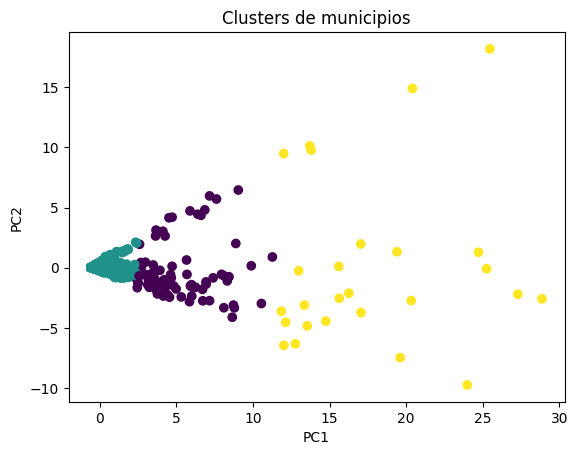

In [55]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters de municipios")
plt.show()